# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [7]:
import yfinance as yf
import pandas as pd

# Definir los tickers y el periodo solicitado
tickers = ["WFC", "TXN", "PG"]
start_date = "2024-01-01"
end_date = "2026-01-01"

# Descargar los datos históricos
datos = yf.download(tickers, start=start_date, end=end_date)

# Mostrar las primeras 5 filas para validar la descarga
display(datos.head())

/tmp/ipykernel_616/2375991892.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed


Price            Close                               High              \
Ticker              PG         TXN        WFC          PG         TXN   
Date                                                                    
2024-01-02  138.312866  156.759201  46.275787  138.935895  157.379716   
2024-01-03  137.475952  154.425323  45.666035  138.740612  156.055333   
2024-01-04  138.229111  152.322937  46.228878  138.805656  153.471361   
2024-01-05  137.085403  152.906418  46.829250  138.433751  153.952951   
2024-01-08  138.266327  156.092377  46.829250  138.480199  156.212780   

Price                         Low                               Open  \
Ticker            WFC          PG         TXN        WFC          PG   
Date                                                                   
2024-01-02  46.679161  136.053209  155.045842  45.797361  136.099707   
2024-01-03  46.050650  136.862217  153.934468  45.328323  137.940901   
2024-01-04  46.772970  137.410811  150.405812  45.750456  137.671181   
2024-01-05  47.345200  136.276398  152.026570  46.238259  138.294272   
2024-01-08  46.894920  137.299227  152.443380  46.106927  137.541009   

Price                               Volume                     
Ticker             TXN        WFC       PG      TXN       WFC  
Date                                                           
2024-01-02  156.379493  46.013121  7238400  5652500  14916000  
2024-01-03  155.583004  46.050650  7697500  5874900  21653600  
2024-01-04  150.498432  45.797359  7067400  6445700  15917500  
2024-01-05  152.721178  46.341449  5294200  3087200  15074800  
2024-01-08  153.008328  46.322687  8255300  5717500  15119700

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

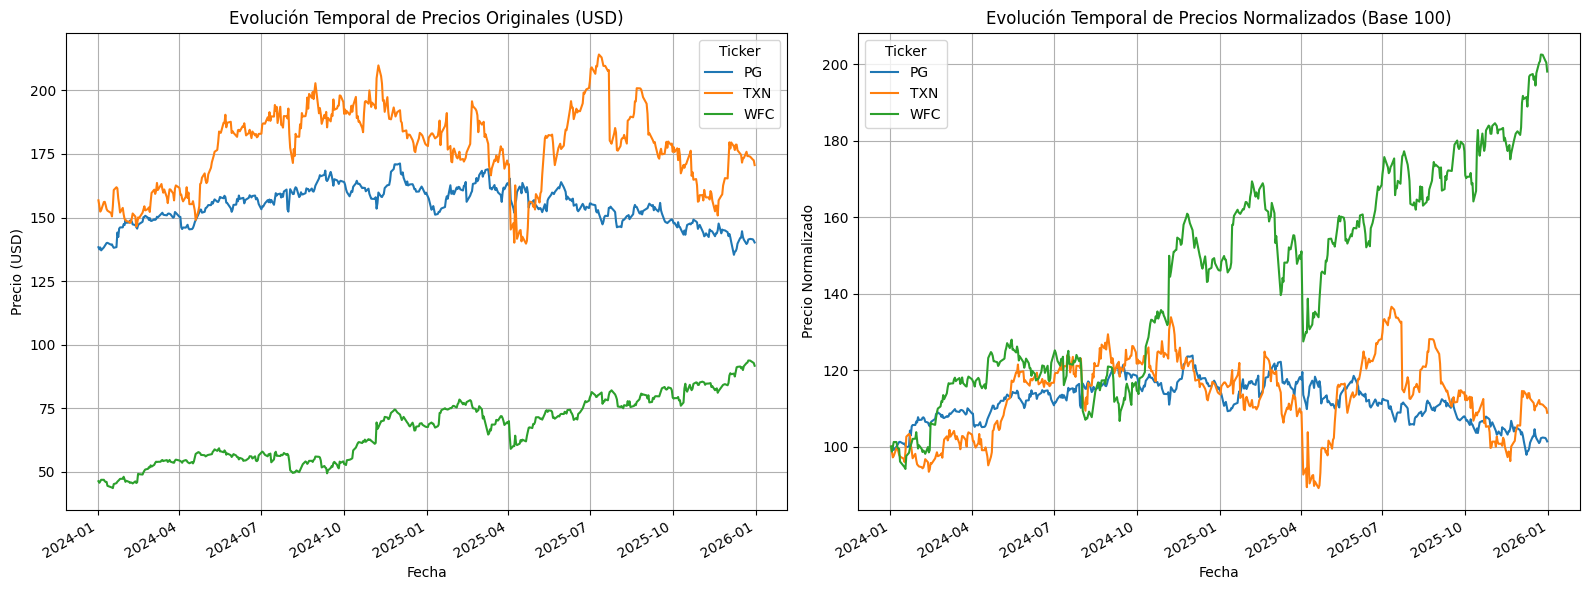

In [8]:
import matplotlib.pyplot as plt

# 1. Extraer únicamente los precios de cierre ('Close')
precios_cierre = datos['Close']

# Crear subplots para visualizar las dos gráficas de manera ordenada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Graficar precios originales
precios_cierre.plot(ax=axes[0])
axes[0].set_title('Evolución Temporal de Precios Originales (USD)')
axes[0].set_ylabel('Precio (USD)')
axes[0].set_xlabel('Fecha')
axes[0].grid(True)

# 3. Normalizar (base 100 en el primer registro) y graficar
precios_normalizados = (precios_cierre / precios_cierre.iloc[0]) * 100
precios_normalizados.plot(ax=axes[1])
axes[1].set_title('Evolución Temporal de Precios Normalizados (Base 100)')
axes[1].set_ylabel('Precio Normalizado')
axes[1].set_xlabel('Fecha')
axes[1].grid(True)

plt.tight_layout()
plt.show()

###  Respuesta a la Pregunta de interpretación #1:

* **¿Por qué es metodológicamente más correcto usar el gráfico normalizado?**  
  Porque los tres activos tienen precios iniciales muy distintos (en dólares reales). Por ejemplo, WFC empieza costando menos de $50 USD, mientras que TXN supera los $150 USD. Si solo vemos los precios reales, es imposible saber cuál creció más en porcentaje. Al **normalizar a Base 100**, hacemos que todos los activos comiencen exactamente en el mismo punto (100). De esta forma, cualquier cambio visual refleja directamente el **rendimiento porcentual acumulado**, permitiendo una comparación justa y real de su desempeño histórico.

* **Diferencia en el comportamiento visual:**
  * **En el gráfico de precios reales**, parece que **TXN** es la mejor opción y el que va ganando porque su línea naranja está físicamente arriba del todo debido a su mayor precio nominal, mientras que **WFC** se ve plano en el fondo.
  * **En el gráfico normalizado**, la perspectiva cambia por completo: descubrimos que **WFC** (línea verde) fue el claro ganador del periodo, llegando a tocar casi un **200% de crecimiento acumulado** (duplicó su valor), mientras que **TXN** y **PG** se quedaron rezagados muy cerca de su nivel de partida original.

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

Volatilidad (Desviación Estándar de Rendimientos Diarios):
Ticker
PG     0.010742
TXN    0.021581
WFC    0.018218
dtype: float64

El activo más volátil es: TXN



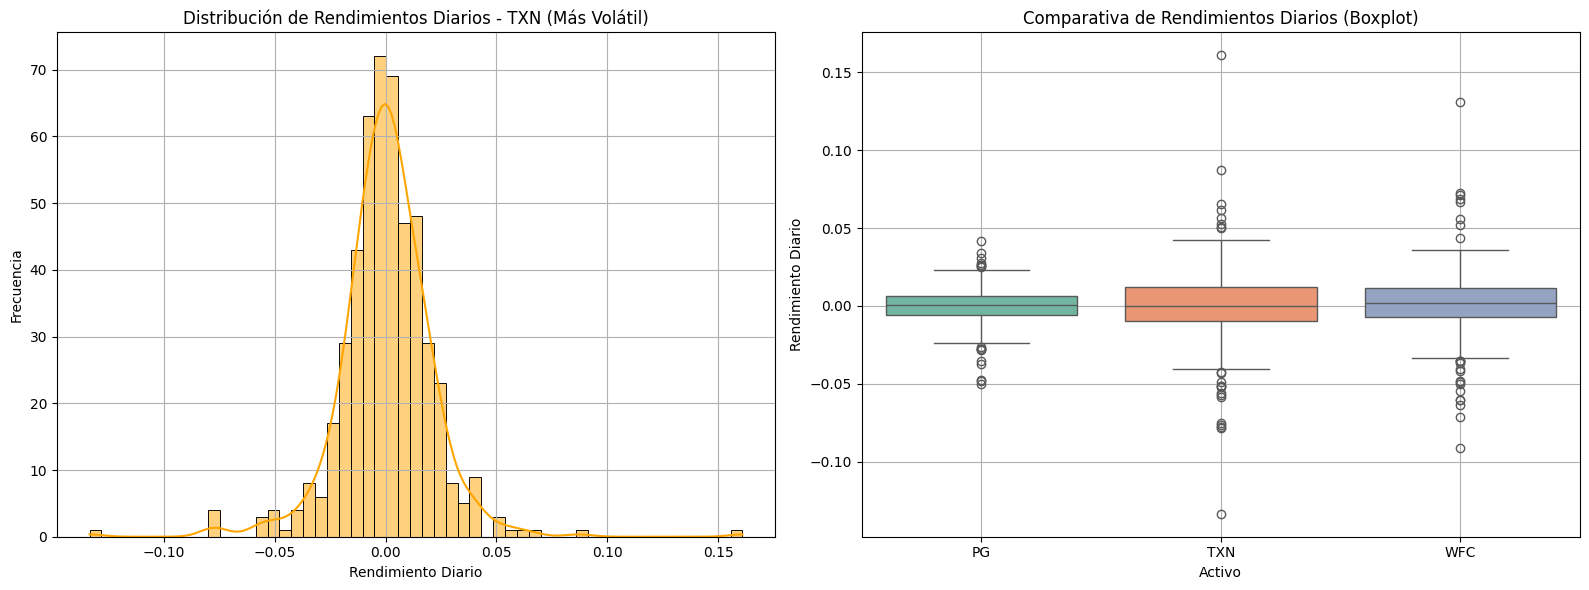

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular los rendimientos diarios y eliminar nulos
rendimientos = precios_cierre.pct_change().dropna()

# Encontrar el activo más volátil usando la desviación estándar
volatilidad = rendimientos.std()
activo_mas_volatil = volatilidad.idxmax()
print("Volatilidad (Desviación Estándar de Rendimientos Diarios):")
print(volatilidad)
print(f"\nEl activo más volátil es: {activo_mas_volatil}\n")

# Configurar las figuras y graficar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Histograma con el activo más volátil
sns.histplot(rendimientos[activo_mas_volatil], kde=True, ax=axes[0], color='orange')
axes[0].set_title(f'Distribución de Rendimientos Diarios - {activo_mas_volatil} (Más Volátil)')
axes[0].set_xlabel('Rendimiento Diario')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True)

# 3. Boxplot comparativo de rendimientos diarios
sns.boxplot(data=rendimientos, ax=axes[1], palette='Set2')
axes[1].set_title('Comparativa de Rendimientos Diarios (Boxplot)')
axes[1].set_ylabel('Rendimiento Diario')
axes[1].set_xlabel('Activo')
axes[1].grid(True)

plt.tight_layout()
plt.show()

###  Respuesta a la Pregunta de interpretación #2:

* ¿Qué activo presenta la mayor dispersión y qué nos dice sobre su riesgo?
  El activo que presenta la mayor dispersión es Texas Instruments TXN. En el Boxplot se observa claramente que tiene la caja más ancha y los bigotes más largos, lo cual se confirma con su desviación estándar que es la más alta del grupo 2.15% diario. Esto significa que TXN es el activo con mayor riesgo del portafolio, ya que sus rendimientos diarios fluctúan con mucha más fuerza que los de PG o WFC, haciéndolo un activo menos predecible.

* ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos?  
  Sí, se identifican bastantes valores atípicos los puntos aislados fuera de los bigotes en el Boxplot para los tres activos, destacando casos muy extremos en TXN con un pico positivo superior al 16% y caídas de hasta -13% y en WFCcon saltos de más del 13%.
  En el contexto económico y empresarial, estos puntos representan **reacciones de pánico o de euforia del mercado ante eventos específicos de gran impacto, tales como:
  1. Reportes trimestrales de ganancias Earnings Reports: Resultados financieros que superaron o decepcionaron drásticamente las expectativas de los analistas.
  2. Anuncios de tasas de la Reserva Federal (Fed):Decisiones macroeconómicas que impactan directamente a la banca como Wells Fargo.
  3. Eventos de la industria: Noticias clave de oferta/demanda de microchips o subsidios gubernamentales como la ley CHIPS en EE. UU. para Texas Instruments.

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Matriz de Correlación de Pearson:


Ticker,PG,TXN,WFC
Ticker,,,
PG,1.000000,0.062275,0.034745
TXN,0.062275,1.000000,0.392848
WFC,0.034745,0.392848,1.000000


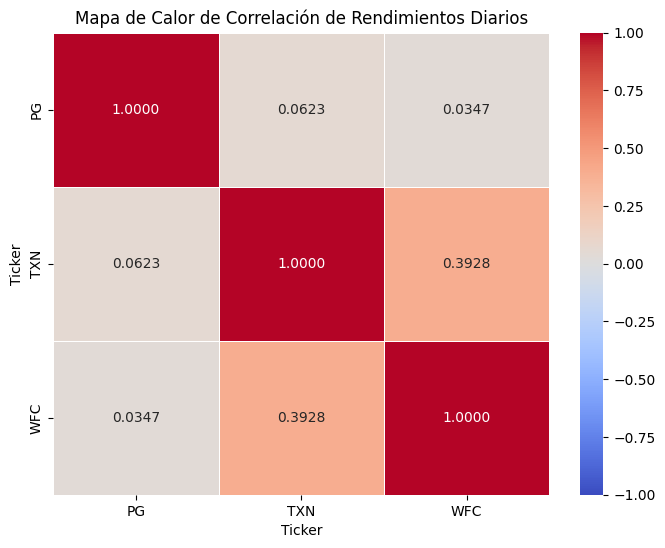

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular la matriz de correlación de Pearson
matriz_correlacion = rendimientos.corr(method='pearson')
print("Matriz de Correlación de Pearson:")
display(matriz_correlacion)

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".4f", linewidths=0.5)
plt.title('Mapa de Calor de Correlación de Rendimientos Diarios')
plt.show()

###  Respuesta a la Pregunta de interpretación #3:

* ¿Existe alguna correlación fuerte cercana a 1 o -1 entre alguno de tus activos?  
  No, no existe ninguna correlación fuerte entre los activos del portafolio.
  * La correlación más alta se da entre TXN y WFC con un valor de 0.3928, lo cual se considera una correlación positiva moderada o débil.
  * Las correlaciones de PG con los demás activos son extremadamente bajas, casi nulas apenas 0.0623 con TXN y 0.0347 con WFC.

* ¿Qué par de activos elegirías para buscar la mejor diversificación y por qué?  
  Para construir un portafolio diversificado que minimice efectivamente el riesgo entre los dos, el par ideal a elegir sería Procter & Gamble PG y Wells Fargo WFC o alternativamente PG y TXN.
  
  ¿Por qué:De acuerdo con la teoría de portafolios de Markowitz, para reducir el riesgo global de una cartera necesitamos activos cuyos movimientos no estén sincronizados baja correlación. Como la correlación entre PG y WFC es prácticamente cero 0.0347, cuando uno de los activos experimente caídas por factores de su industria, el otro se moverá de forma totalmente independiente. Además, esto tiene mucho sentido estratégico y sectorial: combinamos una empresa de consumo defensivo muy estable PG con un banco comercial cíclico WFC.

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos. Mi conslusion final es que e periodo 2024-2026 se revela un comportamiento financiero muy claro y diferenciado para cada activo. por ejemplo WFC Registro el mayor rendimiento diario promedio de 0.1531% con una volatilidad intermedia de 1.82% este es ideal para impulsar el crecimiento de su capital.El activo TXN ES DE ALTO RIESGO: Mostró la mayor volatilidad 2.1581% y oscilaciones extremas peor día de -13.34% y mejor de +16.09%. Aporta alto potencial de crecimiento técnico a costa de mayor riesgo. y el activo PG este es de ancla Defensiva: Con una volatilidad mínima 1.0742%, rindió un promedio menor 0.0085%. Su función clave es proteger su capital y amortiguar las caídas en tiempos de volatilidad.

In [19]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
summary_stats = rendimientos.agg(['mean', 'median', 'std', 'min', 'max'])

# Renombrar los índices para una mejor presentación en español
summary_stats.index = ['Media', 'Mediana', 'Desviación Estándar', 'Mínimo', 'Máximo']

# Mostrar el DataFrame resultante
display(summary_stats)

Ticker,PG,TXN,WFC
Media,0.000085,0.000402,0.001531
Mediana,0.000651,0.000156,0.001685
Desviación Estándar,0.010742,0.021581,0.018218
Mínimo,-0.050119,-0.133399,-0.091198
Máximo,0.041390,0.160879,0.131107
